# NLP Project 2 – Fehleranalyse & Visualisierung
Whisper v1 / v2 / v3 auf STT4SG-350 (Schweizerdeutsch)

**CSV-Spalten:**
- `sentence`   → Ground Truth
- `hypothesis` → Whisper Output
- `canton`     → Kanton (BS, BE, ZH, ...)

**Ablauf:**
1. CSVs laden
2. WER berechnen (overall + pro Kanton)
3. Fehlertypen analysieren (Sub / Del / Ins auf Wortebene)
4. Qualitative Fehlerbeispiele (Top Substitutionen)
5. Visualisierungen für Poster

## 0. Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import re
from collections import Counter
from jiwer import process_words
from jiwer import process_characters


matplotlib.rcParams['figure.dpi'] = 150
os.makedirs('figures', exist_ok=True)

# Spaltennamen
COL_REFERENCE  = 'sentence'
COL_HYPOTHESIS = 'hypothesis'
COL_REGION     = 'canton'

# Pfade zu den Checkpoint-CSVs
RESULTS_DIR = 'results/'
CSV_FILES = {
    'v1': os.path.join(RESULTS_DIR, 'checkpoint_openai_whisper-large.csv'),
    'v2': os.path.join(RESULTS_DIR, 'checkpoint_openai_whisper-large-v2.csv'),
    'v3': os.path.join(RESULTS_DIR, 'checkpoint_openai_whisper-large-v3.csv'),
}

print('Setup complete.')

Setup complete.


## 1. CSVs laden

In [20]:
dfs = {}
for version, path in CSV_FILES.items():
    df = pd.read_csv(path)
    dfs[version] = df
    print(f'Whisper {version}: {df.shape[0]} Samples | Kantone: {sorted(df[COL_REGION].dropna().unique())}')

CANTONS = sorted(dfs['v1'][COL_REGION].dropna().unique())
print(f'\nTotal Kantone ({len(CANTONS)}): {CANTONS}')

Whisper v1: 24605 Samples | Kantone: ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']
Whisper v2: 24605 Samples | Kantone: ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']
Whisper v3: 24605 Samples | Kantone: ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']

Total Kantone (16): ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']


## 2. WER & CER berechnen

In [21]:
def safe_str(text):
    if pd.isna(text):
        return ''
    return str(text).strip().lower()


def compute_metrics(df):
    refs = [safe_str(t) for t in df[COL_REFERENCE]]
    hyps = [safe_str(t) for t in df[COL_HYPOTHESIS]]
    wer_r = process_words(refs, hyps)
    total_errors = wer_r.substitutions + wer_r.deletions + wer_r.insertions
    return {
        'wer':           wer_r.wer,
        'substitutions': wer_r.substitutions,
        'deletions':     wer_r.deletions,
        'insertions':    wer_r.insertions,
        'total_errors':  total_errors,
        'n_samples':     len(df),
    }


# Overall
print('=== Overall WER ===')
overall = {}
for v in ['v1', 'v2', 'v3']:
    overall[v] = compute_metrics(dfs[v])
    r = overall[v]
    print(f'  whisper-large-{v}: WER={r["wer"]*100:.2f}%  '
          f'| Sub={r["substitutions"]}  Del={r["deletions"]}  Ins={r["insertions"]}')

# Pro Kanton
by_canton = {}
for v in ['v1', 'v2', 'v3']:
    by_canton[v] = {}
    for canton in CANTONS:
        df_c = dfs[v][dfs[v][COL_REGION] == canton]
        by_canton[v][canton] = compute_metrics(df_c)

# WER-Tabelle ausgeben
rows = []
for v in ['v1', 'v2', 'v3']:
    for canton in CANTONS:
        r = by_canton[v][canton]
        rows.append({'Modell': f'whisper-large-{v}', 'Kanton': canton,
                     'WER': round(r['wer'], 4), 'N': r['n_samples']})
df_canton = pd.DataFrame(rows)
print('\n=== WER pro Kanton ===')
print(df_canton.pivot(index='Kanton', columns='Modell', values='WER').round(3).to_string())

# Speichern
df_canton.to_csv('results/wer_by_canton.csv', index=False)
pd.DataFrame([{'Modell': f'whisper-large-{v}',
               'WER': round(overall[v]['wer'], 4),
               'N':   overall[v]['n_samples']} for v in ['v1','v2','v3']
             ]).to_csv('results/wer_overall.csv', index=False)
print('\n→ Gespeichert: results/wer_by_canton.csv & wer_overall.csv')

=== Overall WER ===
  whisper-large-v1: WER=29.36%  | Sub=42764  Del=6739  Ins=7979
  whisper-large-v2: WER=25.64%  | Sub=37384  Del=5839  Ins=6964
  whisper-large-v3: WER=24.98%  | Sub=36599  Del=5832  Ins=6466

=== WER pro Kanton ===
Modell  whisper-large-v1  whisper-large-v2  whisper-large-v3
Kanton                                                      
AG                 0.259             0.223             0.214
BE                 0.346             0.302             0.298
BL                 0.348             0.317             0.290
BS                 0.298             0.269             0.250
GL                 0.281             0.247             0.242
GR                 0.266             0.228             0.225
LU                 0.250             0.215             0.212
SG                 0.287             0.249             0.242
SH                 0.187             0.170             0.164
SO                 0.334             0.284             0.253
TG                 0.277        

In [30]:
# ── CER berechnen ─────────────────────────────────────────────────────────────

def compute_cer(df):
    refs = [safe_str(t) for t in df[COL_REFERENCE]]
    hyps = [safe_str(t) for t in df[COL_HYPOTHESIS]]
    cer_r = process_characters(refs, hyps)
    return {
        'cer':           cer_r.cer,
        'substitutions': cer_r.substitutions,
        'deletions':     cer_r.deletions,
        'insertions':    cer_r.insertions,
        'n_samples':     len(df),
    }


# Overall CER
print('=== Overall WER vs CER ===')
print(f'{"Modell":<22} {"WER":>8} {"CER":>8}')
print('-' * 40)

overall_cer = {}
for v in ['v1', 'v2', 'v3']:
    overall_cer[v] = compute_cer(dfs[v])
    wer = overall[v]['wer'] * 100
    cer = overall_cer[v]['cer'] * 100
    print(f'  whisper-large-{v}    {wer:>7.2f}% {cer:>7.2f}%')

# Pro Kanton
by_canton_cer = {}
for v in ['v1', 'v2', 'v3']:
    by_canton_cer[v] = {}
    for canton in CANTONS:
        df_c = dfs[v][dfs[v][COL_REGION] == canton]
        by_canton_cer[v][canton] = compute_cer(df_c)

# Tabelle WER vs CER pro Kanton (für v3 als Beispiel)
print('\n=== WER vs CER pro Kanton (whisper-large-v3) ===')
print(f'{"Kanton":<8} {"WER":>8} {"CER":>8}')
print('-' * 25)
for canton in CANTONS:
    wer = by_canton['v3'][canton]['wer'] * 100
    cer = by_canton_cer['v3'][canton]['cer'] * 100
    print(f'{canton:<8} {wer:>7.1f}% {cer:>7.1f}%')

=== Overall WER vs CER ===
Modell                      WER      CER
----------------------------------------
  whisper-large-v1      29.36%   14.32%
  whisper-large-v2      25.64%   12.53%
  whisper-large-v3      24.98%   12.13%

=== WER vs CER pro Kanton (whisper-large-v3) ===
Kanton        WER      CER
-------------------------
AG          21.4%    10.3%
BE          29.8%    15.7%
BL          29.0%    13.5%
BS          25.0%    11.5%
GL          24.3%    11.4%
GR          22.5%    10.9%
LU          21.2%    10.0%
SG          24.2%    11.5%
SH          16.4%     8.0%
SO          25.3%    12.3%
TG          25.0%    14.1%
TI          19.9%     9.9%
UR          18.8%     8.7%
VS          33.1%    16.0%
ZG          17.7%     8.5%
ZH          20.2%     9.8%


## 3. Fehlertypen-Analyse (Sub / Del / Ins)

In [22]:
print('=== Fehlertypen-Verteilung (Overall) ===')
print(f'{"Modell":<22} {"Sub%":>8} {"Del%":>8} {"Ins%":>8}')
print('-' * 50)

error_types = {}
for v in ['v1', 'v2', 'v3']:
    r  = overall[v]
    te = r['total_errors']
    s  = r['substitutions'] / te if te else 0
    d  = r['deletions']     / te if te else 0
    i  = r['insertions']    / te if te else 0
    error_types[v] = {'sub': s, 'del': d, 'ins': i}
    print(f'  whisper-large-{v}    {s*100:>7.1f}% {d*100:>7.1f}% {i*100:>7.1f}%')

=== Fehlertypen-Verteilung (Overall) ===
Modell                     Sub%     Del%     Ins%
--------------------------------------------------
  whisper-large-v1       74.4%    11.7%    13.9%
  whisper-large-v2       74.5%    11.6%    13.9%
  whisper-large-v3       74.8%    11.9%    13.2%


## 4. Qualitative Fehlerbeispiele (Top-20 Substitutionen pro Modell)

⚠️ Diese Zelle braucht etwas Zeit (~2-3 Min pro Modell wegen sample-weisem Alignment).

In [23]:
def get_top_substitutions(df, top_n=20):
    counter = Counter()
    for _, row in df.iterrows():
        ref = safe_str(row[COL_REFERENCE])
        hyp = safe_str(row[COL_HYPOTHESIS])
        if not ref or not hyp:
            continue
        result    = process_words([ref], [hyp])
        ref_words = ref.split()
        hyp_words = hyp.split()
        for chunk in result.alignments[0]:
            if chunk.type == 'substitute':
                rw = ' '.join(ref_words[chunk.ref_start_idx:chunk.ref_end_idx])
                hw = ' '.join(hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx])
                counter[(rw, hw)] += 1
    return counter.most_common(top_n)


for v in ['v1', 'v2', 'v3']:
    print(f'\n=== Top-20 Substitutionen – Whisper {v} ===')
    print(f'{"Ground Truth":<30} → {"Whisper Output":<30} {"N":>5}')
    print('-' * 68)
    for (rw, hw), cnt in get_top_substitutions(dfs[v]):
        print(f'{rw:<30} → {hw:<30} {cnt:>5}')


=== Top-20 Substitutionen – Whisper v1 ===
Ground Truth                   → Whisper Output                     N
--------------------------------------------------------------------
diese                          → die                              207
dies                           → das                              191
dieses                         → das                              106
nun                            → jetzt                            102
dieser                         → der                               98
die                            → diese                             95
wurden                         → sind                              87
war                            → ist                               75
den                            → der                               74
hatte                          → hat                               73
wurde                          → ist                               71
deshalb                        → darum         

In [ ]:
# ── Linguistische Fehlerkategorien ───────────────────────────────────────────
def categorize_substitutions(df, top_n=200):
    """
    Holt die Top-N Substitutionen und kategorisiert sie automatisch
    in linguistische Fehlerkategorien.
    """
    # Top Substitutionen holen (gleiche Funktion wie vorher)
    pairs = get_top_substitutions(df, top_n=top_n)
    
    categories = {
        'Zahlen':        [],  # "zwanzig" → "20"
        'Eigennamen':    [],  # "Zürich"  → "Zurich"
        'Zerstückelt':   [],  # "Postulat" → "Post und Art"
        'Sonstige Sub':  [],  # alles andere
    }
    
    for (ref_w, hyp_w), cnt in pairs:
        # Zahlen: Hypothesis enthält Ziffern, Referenz nicht
        if re.search(r'\d', hyp_w) and not re.search(r'\d', ref_w):
            categories['Zahlen'].append((ref_w, hyp_w, cnt))
        
        # Zerstückelt: Hypothesis hat deutlich mehr Wörter als Referenz
        elif len(hyp_w.split()) > len(ref_w.split()) + 1:
            categories['Zerstückelt'].append((ref_w, hyp_w, cnt))
        
        # Eigennamen: Referenz-Wort beginnt mit Grossbuchstabe
        elif ref_w and ref_w[0].isupper():
            categories['Eigennamen'].append((ref_w, hyp_w, cnt))
        
        else:
            categories['Sonstige Sub'].append((ref_w, hyp_w, cnt))
    
    return categories


for v in ['v1', 'v2', 'v3']:
    print(f'\n{"="*60}')
    print(f'Linguistische Fehlerkategorien – Whisper {v}')
    print(f'{"="*60}')
    cats = categorize_substitutions(dfs[v])
    for cat_name, items in cats.items():
        print(f'\n── {cat_name} ({len(items)} Einträge) ──')
        for ref_w, hyp_w, cnt in items[:8]:  # Top 8 pro Kategorie
            print(f'  "{ref_w}" → "{hyp_w}"  (n={cnt})')


Linguistische Fehlerkategorien – Whisper v1

── Zahlen (4 Einträge) ──
  "zehn" → "10"  (n=21)
  "fünf" → "5"  (n=12)
  "zwei" → "2"  (n=12)
  "tausend" → "1000"  (n=9)

── Eigennamen (0 Einträge) ──

── Zerstückelt (0 Einträge) ──

── Sonstige Sub (196 Einträge) ──
  "diese" → "die"  (n=207)
  "dies" → "das"  (n=191)
  "dieses" → "das"  (n=106)
  "nun" → "jetzt"  (n=102)
  "dieser" → "der"  (n=98)
  "die" → "diese"  (n=95)
  "wurden" → "sind"  (n=87)
  "war" → "ist"  (n=75)

Linguistische Fehlerkategorien – Whisper v2

── Zahlen (5 Einträge) ──
  "zehn" → "10"  (n=26)
  "fünf" → "5"  (n=18)
  "tausend" → "1000"  (n=11)
  "quadratmeter" → "m2"  (n=10)
  "vier" → "4"  (n=9)

── Eigennamen (0 Einträge) ──

── Zerstückelt (0 Einträge) ──

── Sonstige Sub (195 Einträge) ──
  "dies" → "das"  (n=196)
  "diese" → "die"  (n=184)
  "die" → "diese"  (n=140)
  "wurden" → "sind"  (n=110)
  "dieses" → "das"  (n=106)
  "nun" → "jetzt"  (n=105)
  "deshalb" → "darum"  (n=86)
  "den" → "der"  (n=86)



## 5. Visualisierungen für Poster

In [24]:
V_COLORS = {'v1': '#1976D2', 'v2': '#388E3C', 'v3': '#D32F2F'}
V_LABELS = {'v1': 'Whisper large-v1', 'v2': 'Whisper large-v2', 'v3': 'Whisper large-v3'}
V_SHORT  = {'v1': 'large-v1', 'v2': 'large-v2', 'v3': 'large-v3'}
x_c      = np.arange(len(CANTONS))
width    = 0.25

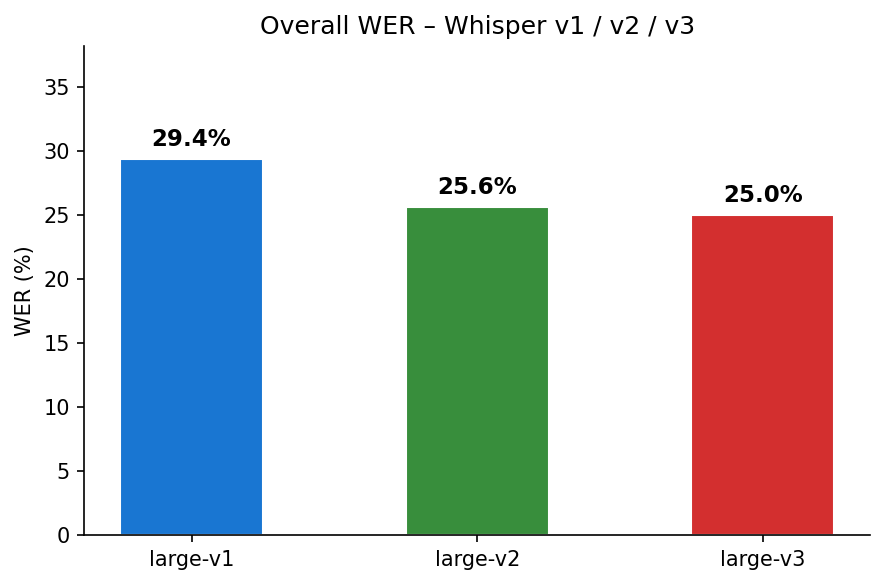

→ figures/fig_wer_overall.png


In [25]:
# ── Fig 1: Overall WER ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
x    = np.arange(3)
wers = [overall[v]['wer'] * 100 for v in ['v1', 'v2', 'v3']]
bars = ax.bar(x, wers, 0.5, color=[V_COLORS[v] for v in ['v1','v2','v3']], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')
ax.set_ylabel('WER (%)')
ax.set_title('Overall WER – Whisper v1 / v2 / v3')
ax.set_xticks(x)
ax.set_xticklabels([V_SHORT[v] for v in ['v1','v2','v3']])
ax.set_ylim(0, max(wers) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_wer_overall.png', dpi=200)
plt.show()
print('→ figures/fig_wer_overall.png')

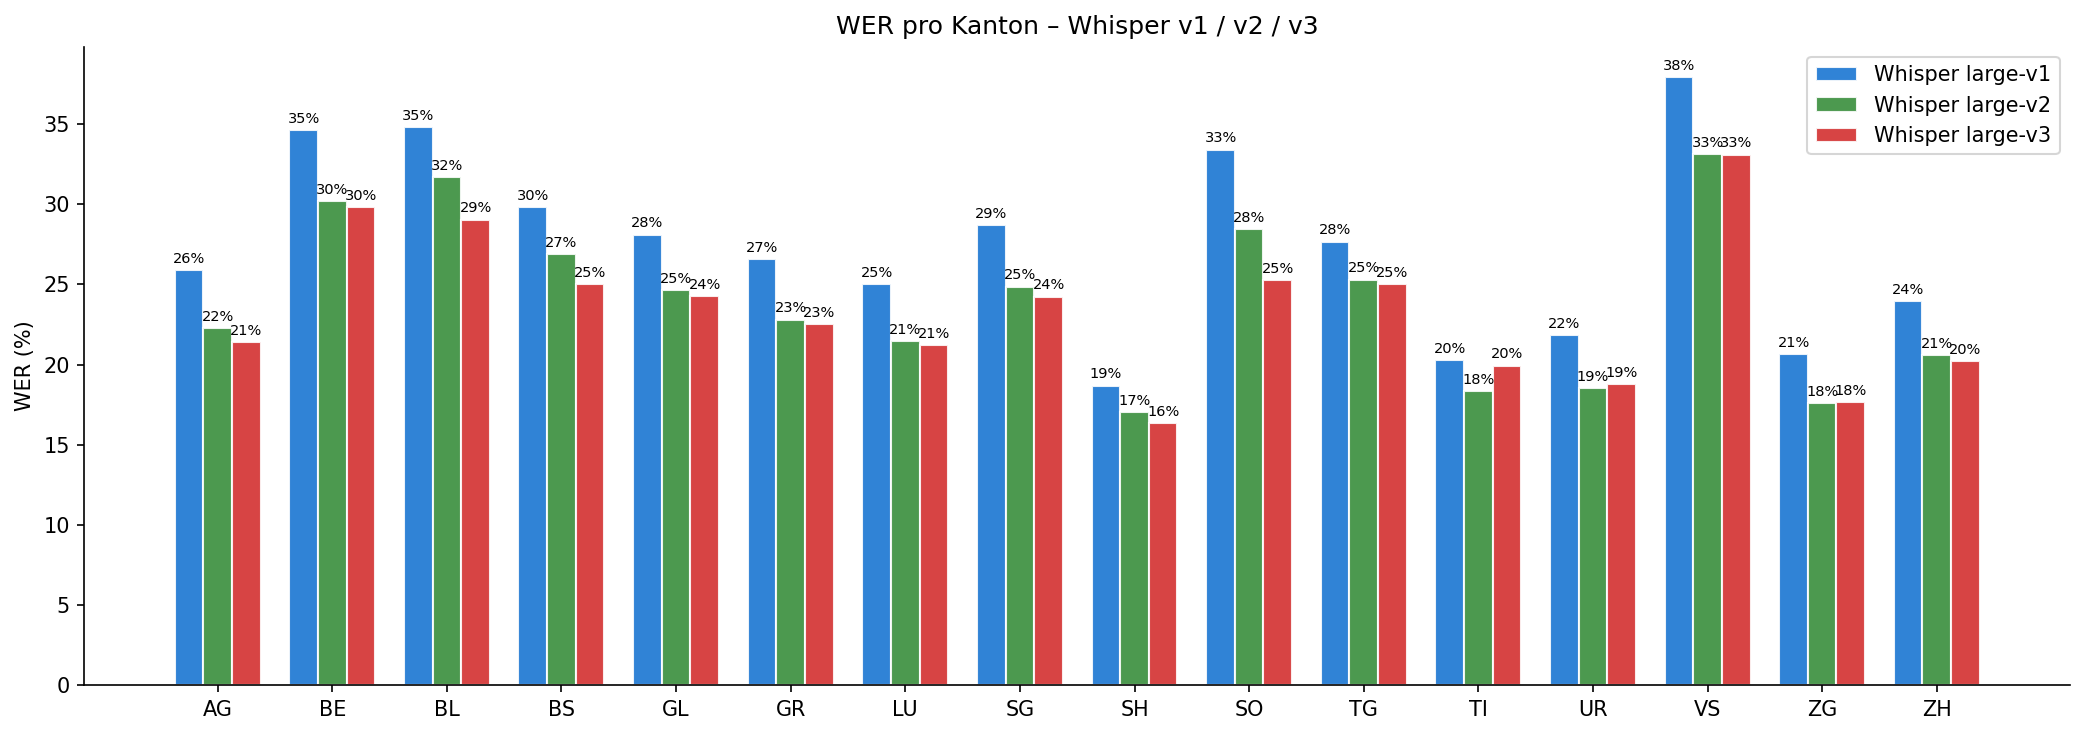

→ figures/fig_wer_by_canton.png


In [26]:
# ── Fig 2: WER pro Kanton ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for i, v in enumerate(['v1', 'v2', 'v3']):
    vals = [by_canton[v][c]['wer'] * 100 for c in CANTONS]
    bars = ax.bar(x_c + (i-1)*width, vals, width,
                  label=V_LABELS[v], color=V_COLORS[v], edgecolor='white', alpha=0.9)
    ax.bar_label(bars, fmt='%.0f%%', padding=2, fontsize=7)
ax.set_ylabel('WER (%)')
ax.set_title('WER pro Kanton – Whisper v1 / v2 / v3')
ax.set_xticks(x_c)
ax.set_xticklabels(CANTONS)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_wer_by_canton.png', dpi=200)
plt.show()
print('→ figures/fig_wer_by_canton.png')

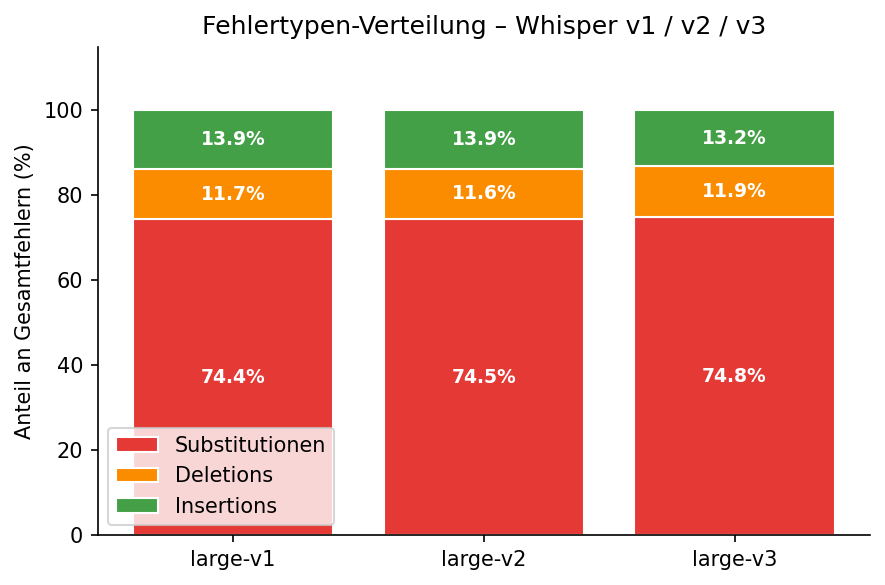

→ figures/fig_error_types.png


In [27]:
# ── Fig 3: Fehlertypen Stacked Bar ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
x3    = np.arange(3)
subs  = [error_types[v]['sub'] * 100 for v in ['v1', 'v2', 'v3']]
dels  = [error_types[v]['del'] * 100 for v in ['v1', 'v2', 'v3']]
ins   = [error_types[v]['ins'] * 100 for v in ['v1', 'v2', 'v3']]
ax.bar(x3, subs, label='Substitutionen', color='#E53935', edgecolor='white')
ax.bar(x3, dels, bottom=subs, label='Deletions', color='#FB8C00', edgecolor='white')
ax.bar(x3, ins,  bottom=[s+d for s,d in zip(subs,dels)], label='Insertions', color='#43A047', edgecolor='white')
for i in range(3):
    if subs[i] > 4: ax.text(i, subs[i]/2,                f'{subs[i]:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if dels[i] > 4: ax.text(i, subs[i]+dels[i]/2,        f'{dels[i]:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if ins[i]  > 4: ax.text(i, subs[i]+dels[i]+ins[i]/2, f'{ins[i]:.1f}%',  ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.set_ylabel('Anteil an Gesamtfehlern (%)')
ax.set_title('Fehlertypen-Verteilung – Whisper v1 / v2 / v3')
ax.set_xticks(x3)
ax.set_xticklabels([V_SHORT[v] for v in ['v1','v2','v3']])
ax.set_ylim(0, 115)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_error_types.png', dpi=200)
plt.show()
print('→ figures/fig_error_types.png')

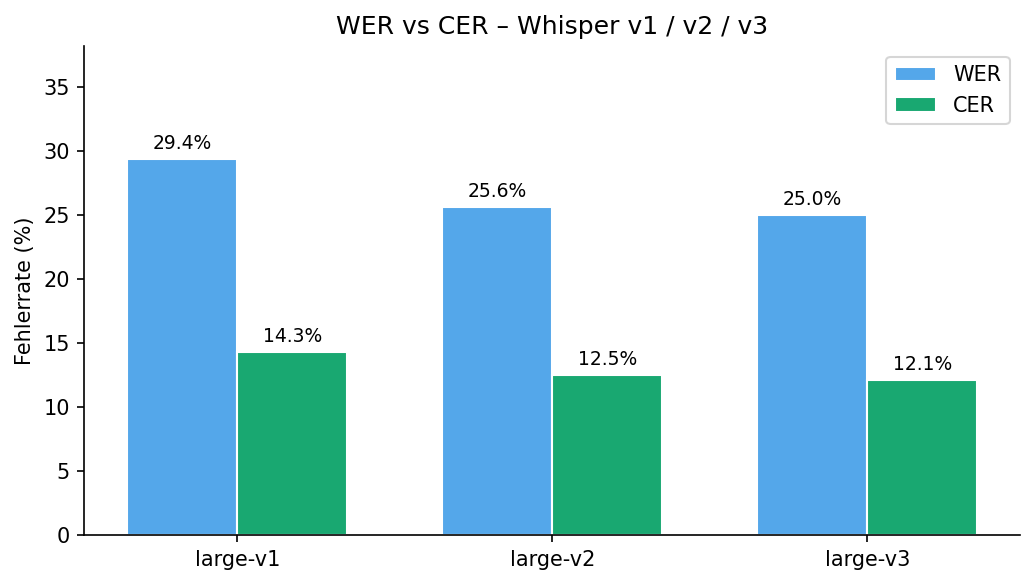

→ figures/fig_wer_vs_cer.png


In [38]:
# ── Fig: WER vs CER Overall (Grouped Bar) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

x     = np.arange(3)
w     = 0.35
wers  = [overall[v]['wer'] * 100 for v in ['v1', 'v2', 'v3']]
cers  = [overall_cer[v]['cer'] * 100 for v in ['v1', 'v2', 'v3']]

b1 = ax.bar(x - w/2, wers, w, label='WER', color="#54A7EA", edgecolor='white')
b2 = ax.bar(x + w/2, cers, w, label='CER', color="#19A871", edgecolor='white')

ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_ylabel('Fehlerrate (%)')
ax.set_title('WER vs CER – Whisper v1 / v2 / v3')
ax.set_xticks(x)
ax.set_xticklabels([V_SHORT[v] for v in ['v1','v2','v3']])
ax.legend(['WER', 'CER'])
ax.set_ylim(0, max(wers + cers) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_wer_vs_cer.png', dpi=200)
plt.show()
print('→ figures/fig_wer_vs_cer.png')

## 6. Zusammenfassung

In [28]:
print('=' * 60)
print('ZUSAMMENFASSUNG')
print('=' * 60)
for v in ['v1', 'v2', 'v3']:
    r     = overall[v]
    best  = min(CANTONS, key=lambda c: by_canton[v][c]['wer'])
    worst = max(CANTONS, key=lambda c: by_canton[v][c]['wer'])
    print(f'\nWhisper large-{v}:')
    print(f'  WER: {r["wer"]*100:.2f}%')
    print(f'  Fehler (Wortebene): Sub={r["substitutions"]}  Del={r["deletions"]}  Ins={r["insertions"]}')
    print(f'  Bester Kanton:        {best}  (WER={by_canton[v][best]["wer"]*100:.1f}%)')
    print(f'  Schlechtester Kanton: {worst} (WER={by_canton[v][worst]["wer"]*100:.1f}%)')

print('\nGenerierte Figures:')
for f in sorted(os.listdir('figures')):
    if f.endswith('.png'):
        print(f'  figures/{f}')

ZUSAMMENFASSUNG

Whisper large-v1:
  WER: 29.36%
  Fehler (Wortebene): Sub=42764  Del=6739  Ins=7979
  Bester Kanton:        SH  (WER=18.7%)
  Schlechtester Kanton: VS (WER=37.9%)

Whisper large-v2:
  WER: 25.64%
  Fehler (Wortebene): Sub=37384  Del=5839  Ins=6964
  Bester Kanton:        SH  (WER=17.0%)
  Schlechtester Kanton: VS (WER=33.1%)

Whisper large-v3:
  WER: 24.98%
  Fehler (Wortebene): Sub=36599  Del=5832  Ins=6466
  Bester Kanton:        SH  (WER=16.4%)
  Schlechtester Kanton: VS (WER=33.1%)

Generierte Figures:
  figures/fig_error_types.png
  figures/fig_wer_by_canton.png
  figures/fig_wer_overall.png
